# Tutorial 09 — LLI/LAM aus Realdaten (Felddaten)

Dieses Tutorial zeigt die **Benutzung** der Felddaten-Pipeline.


**Workflow:**

```
CSV laden  →  30-Tage-Chunks  →  Konsens-Paar (fit_real_data)
     →  Per-Chunk-Auswertung (evaluate_chunks)  →  SOH-Verlauf  →  LLI/LAM-Zeitreihe
```


## Schritt 0 — Imports und Stellschrauben

Die Pipeline besteht aus vier Bausteinen — und einem Block von Stellschrauben, die alle
Filterentscheidungen steuern:

| Konstante | Wirkung |
|-----------|---------|
| `NROWS` | nur die ersten n CSV-Zeilen laden (`None` = alles) — zum Testen |
| `WINDOW_DAYS` | Länge eines Zeitfensters; kleiner = feinere Zeitauflösung, aber weniger Anker je Fenster |
| `MIN_PAUSE_S` | Mindestdauer einer Ruhepause für einen OCV-Anker (Feld: eher lang wählen, die Anker sollen ausrelaxiert sein) |
| `MIN_POINTS_PER_CHUNK` | Fenster mit weniger Ankern werden übersprungen |
| `MAX_RMSE_MV` | Qualitäts-Gate: Fenster, deren *bester* Fit schlechter ist, gelten als kaputte OCV-Wolke |
| `MIN_DSOC_PAIR` | Mindest-SOC-Hub eines Anker-Paars in der Kapazitätsbestimmung |
| `MAX_CYCLING_RATIO` | verwirft Paare, zwischen denen viel hin- und hergeladen wurde |
| `SOC_COVERAGE_MIN` | Mindest-SOC-Abdeckung, damit ein Chunk das gemeinsame Fenster mitbestimmt |
| `CAP_MAD_K` | Stringenz des Kapazitäts-Ausreißerfilters (kleiner = strenger) |

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

import pydpeet as eet

from pydpeet.process.analyze.extract.field_data_loader import (
    load_field_data_csv,    # Feld-CSV (vin-Schema) -> PyDPEET-Spaltenschema
    split_by_time_window,   # Zeitreihe -> Zeitfenster-Chunks
)
from pydpeet.process.analyze.extract.fit_real_data import (
    fit_real_data,          # Konsens-Elektrodenpaar über alle Chunks
    evaluate_chunks,        # Per-Chunk-Pipeline: Fit, Kapazität, Plausibilität
)
from pydpeet.process.analyze.extract.lli_lam import calculate_lli_lam

eet.set_logging_style("ERROR")

CSV_PATH = "../../../input_data/Felddaten/vin38.csv"

NROWS                = None     # None = ganze Datei; zum Testen z. B. 500_000
WINDOW_DAYS          = 30
MIN_PAUSE_S          = 600
MIN_POINTS_PER_CHUNK = 20
MAX_RMSE_MV          = 50.0
MIN_DSOC_PAIR        = 0.02
MAX_CYCLING_RATIO    = 2.0
SOC_COVERAGE_MIN     = 0.60
CAP_MAD_K            = 3.0

## Schritt 1 — Felddaten laden

`load_field_data_csv` bringt das Logger-CSV (vin-Schema: `terminaltime`, `soc`,
`totalcurrent`, `batteryvoltage`, …) in das PyDPEET-Spaltenschema (`Test_Time[s]`,
`Voltage[V]`, `Current[A]`, `SOC`, …) — danach funktionieren alle bestehenden
Extraktions-Funktionen unverändert. Für Parquet-Quellen gibt es analog `load_field_data`.

Nützliche Parameter:

| Parameter | Zweck |
|-----------|-------|
| `nrows` | nur einen Anfangs-Ausschnitt laden (schnelles Testen) |
| `cell_voltage_method` | `"cells_mean"` (Mittel aller Einzelzellen, genau) oder `"minmax_avg"` (deutlich schneller, leichter Bias) |
| `invert_current_sign` | Stromvorzeichen drehen, falls die Quelle die umgekehrte Lade-/Entlade-Konvention nutzt |
| `soc_scale` | Skalierung des Quell-SOC (Default 0.01: Prozent → Anteil 0…1) |
| `start_time_s`, `end_time_s` | Ausschnitt in Sekunden `terminaltime` |

Geladen: 4,132,658 Samples, 940 Tage, SOC 0.02 … 1.00


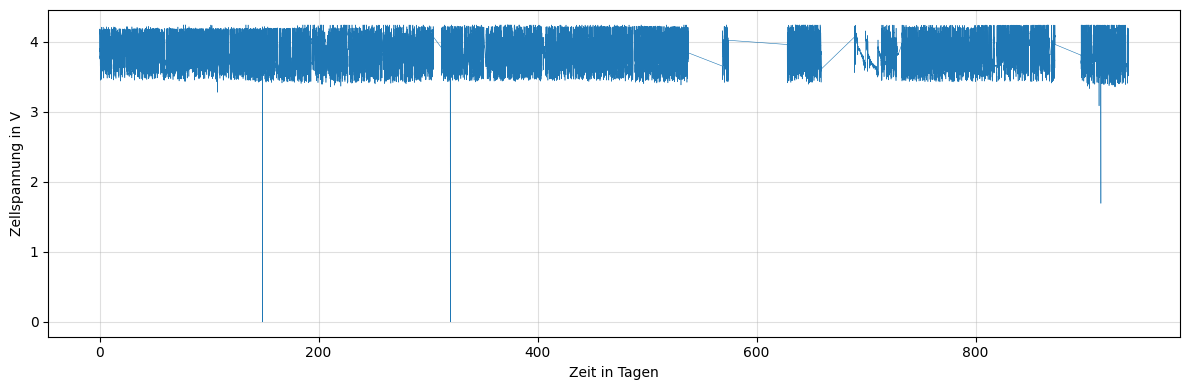

In [10]:
df_field = load_field_data_csv(CSV_PATH, nrows=NROWS)
print(f"Geladen: {len(df_field):,} Samples, {df_field['Test_Time[s]'].iloc[-1]/86400:.0f} Tage, "
      f"SOC {df_field['SOC'].min():.2f} … {df_field['SOC'].max():.2f}")

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df_field["Test_Time[s]"] / 86400, df_field["Voltage[V]"], lw=0.4, color="tab:blue")
ax.set_xlabel("Zeit in Tagen")
ax.set_ylabel("Zellspannung in V")
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

## Schritt 2 — In Zeitfenster teilen

`split_by_time_window` schneidet die Zeitreihe in aufeinanderfolgende Fenster von
`WINDOW_DAYS` Tagen. Jeder Chunk wird später als ein Alterungszustand behandelt.


In [ ]:
chunks = split_by_time_window(df_field, window_days=WINDOW_DAYS)
print(f"{len(chunks)} Chunks a {WINDOW_DAYS} Tage")

32 Chunks à 30 Tage


## Schritt 3 — Konsens-Elektrodenpaar finden

`fit_real_data` erledigt die Chemie-Identifikation in einem Aufruf. Intern läuft je Chunk:
Ruhepausen → OCV-Anker → Bibliotheks-Grid-Search über alle Elektrodenpaare, anschließend
werden Fenster mit zu schlechtem "besten" Fit verworfen (`max_rmse_mv`) und die Paare nach
ihrem **Median-RMSE über alle behaltenen Fenster** gerankt. Zeile 1 ist das Konsens-Paar.

Ausgabespalten:

| Spalte | Bedeutung |
|--------|-----------|
| `Anode`, `Cathode` | Dateinamen der Referenz-Halbzellen |
| `n_chunks` | in wie vielen behaltenen Fenstern das Paar fitbar war |
| `median_rmse`, `mean_rmse`, `max_rmse` | Fit-Güte über die Fenster in mV |
| `wins` | in wie vielen Fenstern das Paar der beste Fit war |

Weitere Optionen: `sort_by` (`"median"`, `"mean"`, `"wins"`), eigene Bibliothek über
`anodes_dir`/`cathodes_dir`, `max_workers` (Fits laufen parallel)


In [4]:
consensus = fit_real_data(
    df_field,
    window_days=WINDOW_DAYS,
    min_pause_duration_s=MIN_PAUSE_S,
    min_points=MIN_POINTS_PER_CHUNK,
    max_rmse_mv=MAX_RMSE_MV,
)

top = consensus.iloc[0]
print(f"\nKonsens-Paar: {top['Anode']}  +  {top['Cathode']}  "
      f"(median RMSE {top['median_rmse']:.1f} mV über {top['n_chunks']} Chunks, {top['wins']} Siege)")
consensus.head(5).round(2)

chunk  1: nur 17 OCV-Punkte → übersprungen
chunk  2: nur 19 OCV-Punkte → übersprungen
chunk  3: nur 15 OCV-Punkte → übersprungen
chunk 10: nur 19 OCV-Punkte → übersprungen
chunk 17: nur 17 OCV-Punkte → übersprungen
chunk 18: nur 5 OCV-Punkte → übersprungen
chunk 19: nur 4 OCV-Punkte → übersprungen
chunk 20: nur 4 OCV-Punkte → übersprungen
chunk 22: nur 3 OCV-Punkte → übersprungen
chunk 29: nur 10 OCV-Punkte → übersprungen
chunk 31: nur 13 OCV-Punkte → übersprungen
chunk  4:  28 Punkte → fit OK
chunk  7:  27 Punkte → fit OK
chunk  9:  30 Punkte → fit OK
chunk 14:  29 Punkte → fit OK
chunk 11:  28 Punkte → fit OK
chunk  8:  32 Punkte → fit OK
chunk  6:  22 Punkte → fit OK
chunk 12:  25 Punkte → fit OK
chunk  5:  23 Punkte → fit OK
chunk  0:  32 Punkte → fit OK
chunk 13:  34 Punkte → fit OK
chunk 15:  34 Punkte → fit OK
chunk 16:  30 Punkte → fit OK
chunk 30:  27 Punkte → fit OK
chunk 25:  31 Punkte → fit OK
chunk 26:  35 Punkte → fit OK
chunk 24:  36 Punkte → fit OK
chunk 27:  32 Punkte 

,Anode,Cathode,n_chunks,median_rmse,mean_rmse,max_rmse,wins
0,"Graphite, Chaouachi2021.csv","NMC622, Chaouachi2021.csv",16,15.48,16.55,36.27,4
1,"Graphite, Ecker2015.csv","NMC622, Chaouachi2021.csv",16,15.85,16.63,37.50,2
2,"Graphite, Schmalstieg2018.csv","NMC622, Chaouachi2021.csv",16,15.99,16.72,37.12,0
3,"Graphite-Silicon, Chen2020.csv","NMC622, Chaouachi2021.csv",16,16.03,16.71,36.83,0
4,"Graphite, Hust2019.csv","NMC622, Gao2018.csv",16,16.06,17.46,38.18,0


## Schritt 4 — Per-Chunk-Auswertung gegen das feste Paar

`evaluate_chunks` wertet jeden Chunk gegen das Konsens-Paar aus.



Wichtige Einträge im Rückgabe-Dictionary:

| Key | Inhalt |
|-----|--------|
| `overview` | fertige Übersichtstabelle (eine Zeile je Chunk) |
| `soh_ids` | Chunk-Indizes, die alle Filter überstanden haben |
| `cap_per_chunk_mAh`, `cap_ref_mAh` | Kapazität je Chunk und SOH-Referenz (Median der ersten plausiblen Chunks) |
| `quantities_per_chunk` | Elektrodengrößen je Chunk — Eingang für `calculate_lli_lam` |
| `global_window` | verwendetes gemeinsames SOC-Fenster |


In [5]:
res = evaluate_chunks(
    chunks, top["Anode"], top["Cathode"],
    min_pause_duration_s=MIN_PAUSE_S,
    min_points=MIN_POINTS_PER_CHUNK,
    max_rmse_mv=MAX_RMSE_MV,
    min_dsoc_pair=MIN_DSOC_PAIR,
    max_cycling_ratio=MAX_CYCLING_RATIO,
    soc_coverage_min=SOC_COVERAGE_MIN,
    cap_mad_k=CAP_MAD_K,
)

res["overview"]

Gemeinsames SOC-Fenster über 16 Chunks: 0.367 .. 0.932  (Breite 0.565)
11 Chunks mit gültiger Kapazität: [0, 5, 6, 8, 11, 12, 15, 16, 23, 24, 28]
Cap-Ausreißer (> 3*MAD um Median 115.7 Ah): [23]
-> plausible Chunks: 10 [0, 5, 6, 8, 11, 12, 15, 16, 24, 28]
SOH-Referenzkapazität (Median der ersten 3 plausiblen Chunks): 128.3 Ah


,chunk,RMSE_mV,Cap_Ah,SOH_pct,C_Anode_Ah,C_Cathode_Ah,Cap_plausibel
0,0,9.53,128.29,100.00,371.25,243.07,True
1,5,17.00,107.40,83.72,140.42,202.49,True
2,6,22.18,140.05,109.17,405.93,256.99,True
3,8,24.69,108.85,84.85,172.13,206.05,True
4,11,17.31,126.95,98.96,152.10,233.88,True
5,12,17.33,108.17,84.32,133.44,210.36,True
6,15,14.06,114.61,89.34,139.53,208.12,True
7,16,9.10,112.41,87.62,155.77,203.79,True
8,23,15.51,150.85,117.58,190.82,277.33,False
9,24,15.44,134.86,105.12,140.44,237.83,True




## Schritt 5 — SOH-Verlauf

.

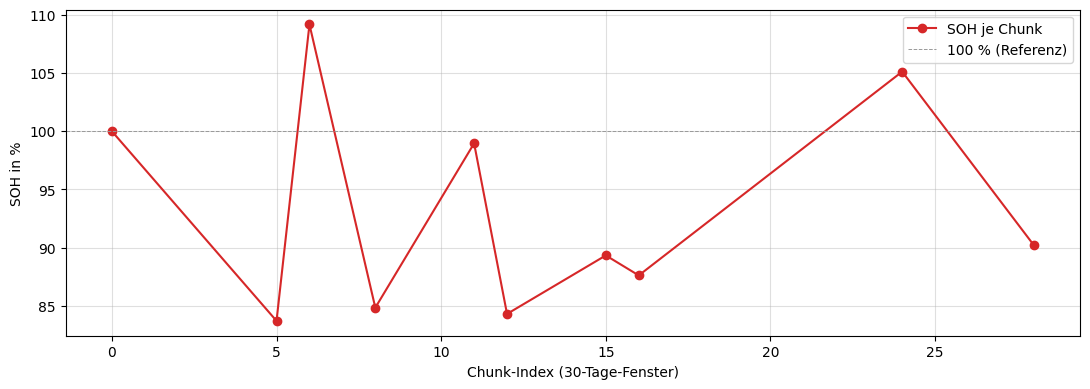

In [6]:
soh_ids = res["soh_ids"]
soh_pct = [res["cap_per_chunk_mAh"][i] / res["cap_ref_mAh"] * 100 for i in soh_ids]

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(soh_ids, soh_pct, "o-", color="tab:red", label="SOH je Chunk")
ax.axhline(100, color="0.6", lw=0.7, ls="--", label="100 % (Referenz)")
ax.set_xlabel(f"Chunk-Index ({WINDOW_DAYS}-Tage-Fenster)")
ax.set_ylabel("SOH in %")
ax.grid(True, alpha=0.4)
ax.legend()
plt.tight_layout()
plt.show()

## Schritt 6 — LLI/LAM-Zeitreihe

`calculate_lli_lam` vergleicht die Elektrodengrößen zweier Chunks. Ausgewertet wird
**kumulativ**: jeder plausible Chunk gegen den ersten plausiblen Chunk — das ergibt die
Gesamtdegradation seit Beobachtungsbeginn.

Zur Einordnung gilt dasselbe wie im CheckUp-Fall: positive Werte = Verlust, LAM ist
unsicherer als SOH und LLI (Fenster-Identifikation auf Teilabdeckung).

In [ ]:
quantities = res["quantities_per_chunk"]
cols = ["ref_chunk", "chunk", "SOH_pct", "LLI_pct", "LAM_Anode_pct", "LAM_Cathode_pct"]

if len(soh_ids) < 2:
    print(f"Nur {len(soh_ids)} plausibler Chunk — für eine LLI/LAM-Zeitreihe sind mindestens 2 nötig.")
else:
    ref0 = soh_ids[0]
    kumulativ = pd.concat(
        [calculate_lli_lam(quantities[ref0], quantities[c]).assign(ref_chunk=ref0, chunk=c)
         for c in soh_ids[1:]],
        ignore_index=True,
    )
    print(f"Kumulativ (vs. Chunk {ref0}):")
    print(kumulativ[cols].round(2).to_string(index=False))

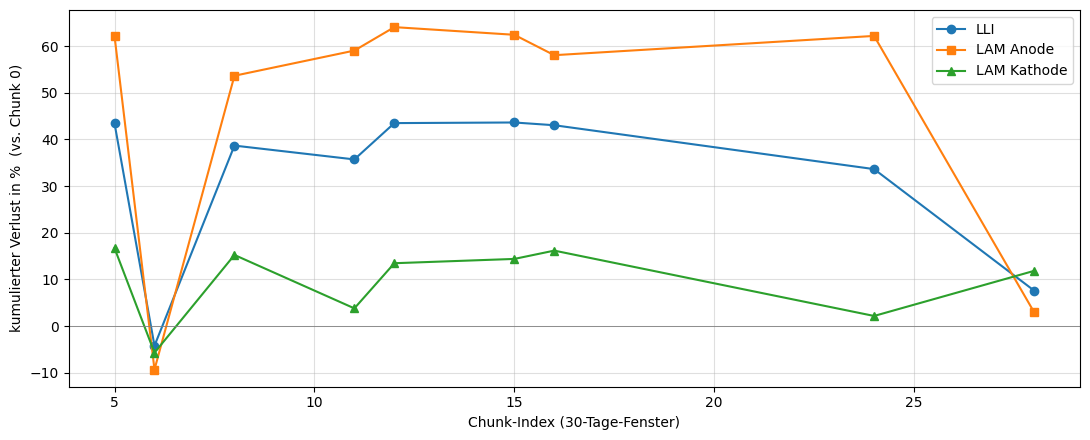

In [8]:
if len(soh_ids) >= 2:
    x = kumulativ["chunk"].to_numpy()
    fig, ax = plt.subplots(figsize=(11, 4.5))
    ax.plot(x, kumulativ["LLI_pct"],         "o-", color="tab:blue",   label="LLI")
    ax.plot(x, kumulativ["LAM_Anode_pct"],   "s-", color="tab:orange", label="LAM Anode")
    ax.plot(x, kumulativ["LAM_Cathode_pct"], "^-", color="tab:green",  label="LAM Kathode")
    ax.axhline(0, color="0.5", lw=0.6)
    ax.set_xlabel(f"Chunk-Index ({WINDOW_DAYS}-Tage-Fenster)")
    ax.set_ylabel(f"kumulierter Verlust in %  (vs. Chunk {soh_ids[0]})")
    ax.grid(True, alpha=0.4)
    ax.legend()
    plt.tight_layout()
    plt.show()